In [1]:
import mdtraj as md
import numpy as np
import scipy
from scipy.stats import linregress
import matplotlib.pyplot as plt
from itertools import combinations
import sys, os, re
from msmbuilder.decomposition import tICA as msm_tICA
from msmbuilder.featurizer import AtomPairsFeaturizer

sys.path.append(os.path.dirname(os.getcwd())) 
import amuset_tica

In [2]:
tics_of_trajs = np.load("Ala-lag0.1ps-first5tICs-msmbuild.npy")[:, ::10, :]
print(tics_of_trajs.shape)
basis_list = [[[-1.43747934, 2], [ 0.66571087, 2], [-0.14983666, 2], [5.10290513, 2]], [[-1.43747934, 2], [ 0.66571087, 2], [-0.14983666, 2], [5.10290513, 2]]]
print(basis_list)

lag_times = list(range(1, 51))
traj_AT, traj_lens = amuset_tica._convert_sequences(tics_of_trajs)
print(traj_AT.shape)

(100, 10001, 5)
[[[-1.43747934, 2], [0.66571087, 2], [-0.14983666, 2], [5.10290513, 2]], [[-1.43747934, 2], [0.66571087, 2], [-0.14983666, 2], [5.10290513, 2]]]
(5, 1000100)


In [10]:
RNG = []
with open('random-number-100.txt', 'r') as f:
    i = 0
    for line in f:
        i += 1
        if i > 50:
            break
        RNG.append(list(map(int, line.split())))

len(RNG), len(RNG[0])

(50, 100)

In [4]:
ttica = amuset_tica.AmusetTICA()
svd_v, _ = ttica.build(basis_list, tics_of_trajs)
svd_full = amuset_tica._convert_to_sequences(svd_v, traj_lens)
print(len(svd_full), svd_full[0].shape)

100 (10001, 25)


In [7]:
lag_times = list(range(1, 51))
Koop_boot = []

for j in range(50):
    svd_v_resam = [svd_full[_] for _ in RNG[j]]
    svd_v_cur, traj_lens_cur = amuset_tica._convert_sequences(svd_v_resam)
    Koop_collect = []
    for i in lag_times:
        ttica.covariance(svd_v_cur, traj_lens_cur, lag_time=i)
        Koop_collect.append(ttica._K)
        if i % 15 == 0:
            print("Time =", i, 'frames')
    Koop_boot.append(np.array(Koop_collect))
    print('Round#', j, 'Bootstraping')

Koop_boot = np.array(Koop_boot)
from datetime import datetime
print(f"Current date and time: {datetime.now()}")

Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 1 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 2 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 3 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 4 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 5 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 6 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 7 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 8 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 9 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 10 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 11 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 12 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 frames
Round# 13 Bootstraping
Time = 15 frames
Time = 30 frames
Time = 45 fra

In [12]:
print(Koop_boot.shape)
note = '(n_bootstrap, n_lag_times, Rank, Rank); Bootstraping with 100 trajs for 50 times, and run for all 50 different lag times.'
np.savez('Koopman_bootstrap.npz', data=Koop_boot, lag=lag_times, note=note)

(50, 50, 25, 25)


In [13]:
load_data = np.load('Koopman_bootstrap.npz')
load_data, load_data['data'].shape

(NpzFile 'Koopman_bootstrap.npz' with keys: data, lag, note, (50, 50, 25, 25))

# regression

In [15]:
load_data = np.load('Koopman_bootstrap.npz')
Ks_boot, lag_boot = load_data['data'], load_data['lag']
Ks = np.load("Ks25.npy")
lag_times = range(1, 51)
st, en = 13, 21
print(Ks.shape, Ks_boot.shape)

(50, 25, 25) (50, 50, 25, 25)


In [16]:
# ============================================================
# 1. Core regression: fit M from K(t+1) ≈ K(t) M
# ============================================================

def fit_M_from_K_sequence(Ks, st=0, gap=1, num_pair=None, enforce_hermitian_M=False, rcond=None):
    """
    Fit M in the model K(t+1) ≈ K(t) M via least squares.

    Parameters
    ----------
    Ks : list or array-like of shape [T, d, d]
        Sequence of Hermitian (or general) matrices K(t),
        t = 0, ..., T-1.
    enforce_hermitian_M : bool, optional
        If True, M is projected onto the Hermitian cone:
        M <- (M + M^†) / 2
    rcond : float or None
        Passed to np.linalg.lstsq for numerical stability.

    Returns
    -------
    M : (d, d) np.ndarray
        Estimated propagator.
    info : dict
        Some diagnostics: residuals, norms, etc.
    """
    Ks = np.asarray(Ks)
    T, d1, d2 = Ks.shape
    assert d1 == d2, "K(t) must be square."
    if st < 0:
        st = T - st
    assert gap > 0, 'gap must be positive.'
    d = d1

    if T < st + gap + 1:
        raise ValueError("Need at least 2 valid matrices K(t) to fit M.")

    # Build stacked system:
    #   X M ≈ Y
    # where X = block rows of K(0..T-2), Y = block rows of K(1..T-1)
    X = Ks[st:-gap].reshape(-1, d)
    Y = Ks[st+gap:].reshape(-1, d)

    # Solve least squares: X M ≈ Y
    # np.linalg.lstsq handles complex numbers and uses SVD internally.
    M, residuals, rank, s = np.linalg.lstsq(X, Y, rcond=rcond)

    if enforce_hermitian_M:
        M = 0.5 * (M + M.conj().T)

    # Compute residuals in matrix form: R(t) = K(t+1) - K(t) M
    R_list = []
    rel_norms = []
    end_point = T-gap
    if num_pair and num_pair < end_point - st:
        end_point = st+num_pair
    for t in range(st, end_point):
        K_pred = Ks[t] @ M
        R = Ks[t + gap] - K_pred
        R_list.append(R)
        num = np.linalg.norm(R, ord="fro")
        den = np.linalg.norm(Ks[t + gap], ord="fro") + 1e-15
        rel_norms.append(num / den)

    info = {
        "residuals": np.array(R_list),      # shape: (T-1, d, d)
        "relative_residual_norms": np.array(rel_norms),  # length T-1
        "lstsq_residuals_raw": residuals,
        "rank_X": rank,
        "singular_values_X": s,
    }

    return M, info


# ============================================================
# 2. Fit A from K(0) ≈ A M
# ============================================================

def fit_A_from_K0_and_M(K0, M):
    """
    Fit A in the model K(0) ≈ A M using pseudoinverse.

    Parameters
    ----------
    K0 : (d, d) array
        First matrix in the sequence, K(0).
    M : (d, d) array
        Propagator matrix.

    Returns
    -------
    A : (d, d) array
    """
    M_pinv = np.linalg.pinv(M)
    A = K0 @ M_pinv
    return A


# ============================================================
# 3. Generate predicted K(t) from A and M
# ============================================================

def generate_K_from_A_M(A, M, T):
    """
    Generate model-predicted K(t) = A M^t for t = 0..T-1.

    Parameters
    ----------
    A : (d, d) array
    M : (d, d) array
    T : int
        Number of time steps.

    Returns
    -------
    K_model : (T, d, d) array
    """
    d = A.shape[0]
    K_model = np.zeros((T, d, d), dtype=complex if np.iscomplexobj(A) or np.iscomplexobj(M) else float)
    Mt = np.eye(d, dtype=K_model.dtype)
    for t in range(T):
        Mt = Mt @ M
        K_model[t] = A @ Mt
    return K_model


In [17]:
st, en = 13, 21

M_hat, info = fit_M_from_K_sequence(Ks[:en], st, 1, enforce_hermitian_M=False)
print_regression_summary(info)
A_hat = fit_A_from_K0_and_M(Ks[st], M_hat)
Ks_model = generate_K_from_A_M(A_hat, M_hat, len(Ks)-st)

print(Ks_model.shape)
print(Ks[en:].shape)
# Optional: uncertainties
#Ms_boot, M_mean, M_std = bootstrap_M(Ks, n_boot=200, random_state=0)

=== Regression summary (K(t+1) ≈ K(t) M) ===
Number of time steps used: 7
Relative residual norms (per step): [0.0231533  0.02889165 0.02637032 0.02273302 0.02263566 0.02278466
 0.0250916 ]
Mean relative residual norm: 2.452e-02
Median relative residual norm: 2.315e-02
Rank(X): 25
Singular values of X: [2.64575134 2.59845195 2.00860682 1.06723258 0.08675301 0.05659516
 0.03827216 0.03558525 0.03290191 0.03133334 0.02764564 0.02510743
 0.01814373 0.01277561 0.01176171 0.00964819 0.00914589 0.00856822
 0.00814104 0.00707734 0.00667811 0.00655955 0.00586553 0.00526633
 0.00491553]
(37, 25, 25)
(29, 25, 25)


In [22]:
# Ks_loop start with lag=1ps 
K_mean, K_std = [], []
for lt in range(st, 50):
    cur_mean, cur_std = np.zeros((25, 25), dtype=np.float64), np.zeros((25, 25), dtype=np.float64)
    for i in range(25):
        for j in range(25):
            arr = Ks_boot[:, lt, i, j]
            cur_mean[i][j], cur_std[i][j] = np.mean(arr), np.std(arr)
    K_mean.append(cur_mean)
    K_std.append(cur_std)
print(len(K_mean), K_mean[0].shape)

37 (25, 25)


In [21]:
Ks[st:].shape, Ks_model.shape

((37, 25, 25), (37, 25, 25))

In [26]:
def plot_all_entries(Ks_true, Ks_model, r, c, y_lim_range = .01, fig_size = (18, 18)):
    
    Ks_true = np.asarray(Ks_true)
    Ks_model = np.asarray(Ks_model)
    t = np.arange(len(Ks_true))
    
    fig, axes = plt.subplots(r, c, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for i in range(r):
        for j in range(c):
            ax = axes[i, j]
            y_true = Ks_true[:, i, j]
            y_pred = Ks_model[:, i, j]
            
            if True:#i!=j:
                max_true, min_true = np.max(y_true), np.min(y_true)
                if max_true - min_true < y_lim_range:
                    mid_true = .5* (max_true + min_true)
                    ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
                else:
                    ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])
            
            ax.plot(t, y_true, label="true", color="black")
            ax.plot(t, y_pred, linestyle="dashdot", color="orange")
            ax.set_title(f"[{i},{j}]", fontsize=8)
            # Smaller ticks for large grid
            ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.show()

def plot_error_bar(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (18, 18)):
    Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))
    fig, axes = plt.subplots(int(np.ceil(length/size)), size, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for idx in range(length):
        ax = axes[idx//size, idx%size]
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.plot(t, y_pred, linestyle="dashdot", label='Predicted K', color="orange")
        ax.errorbar(t, y_true, yerr=y_err, fmt='o', capsize=3, color="black", label='True w/ 1sigma')
        ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.xticks([])
    plt.show()


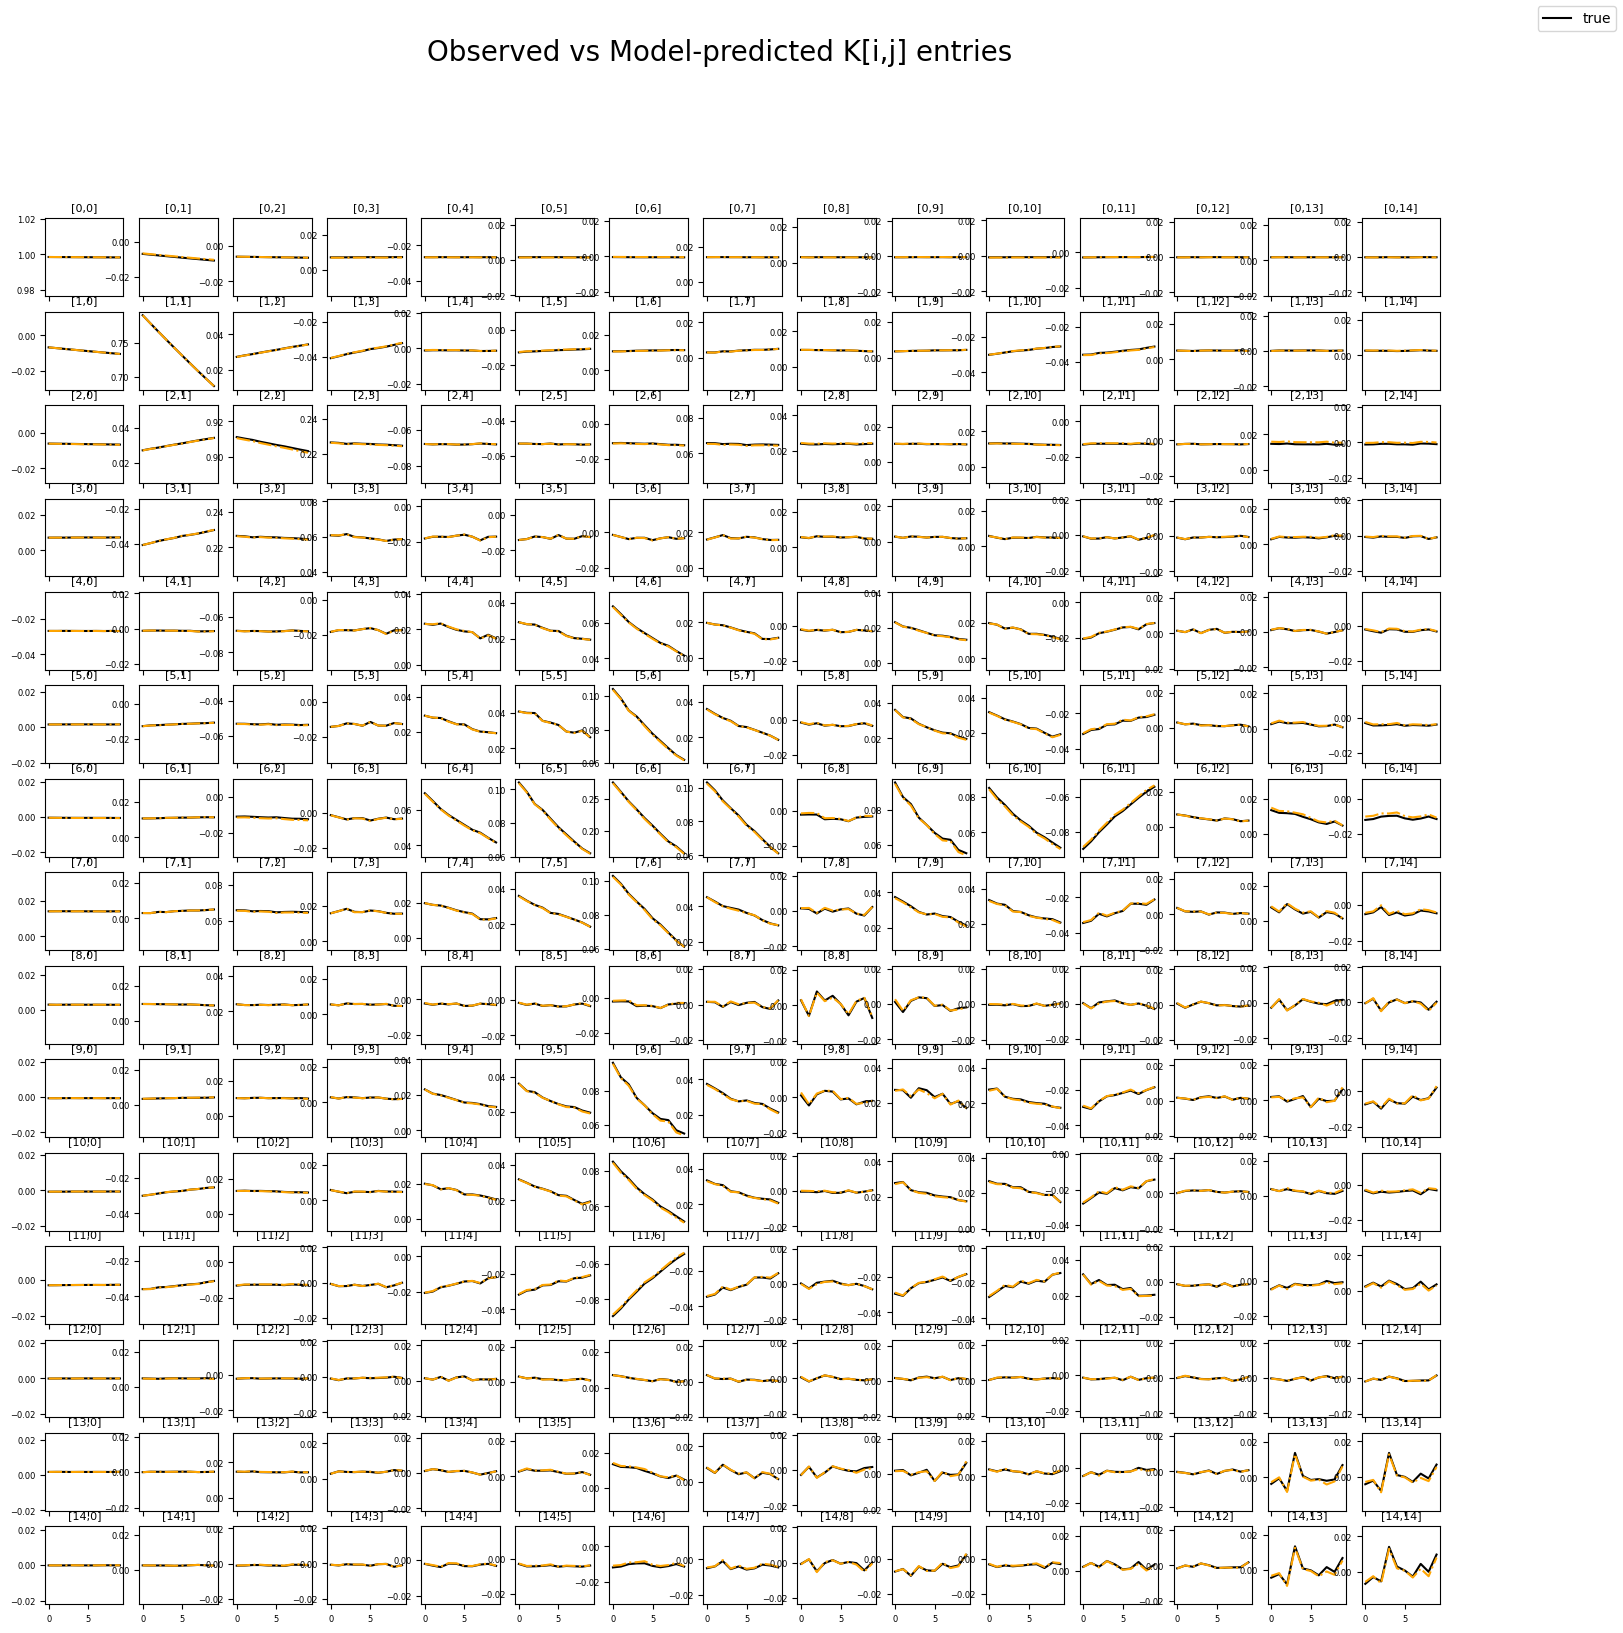

In [24]:
plot_all_entries(Ks[st:st+10], K_mean[:10], 15, 15, y_lim_range=.04)

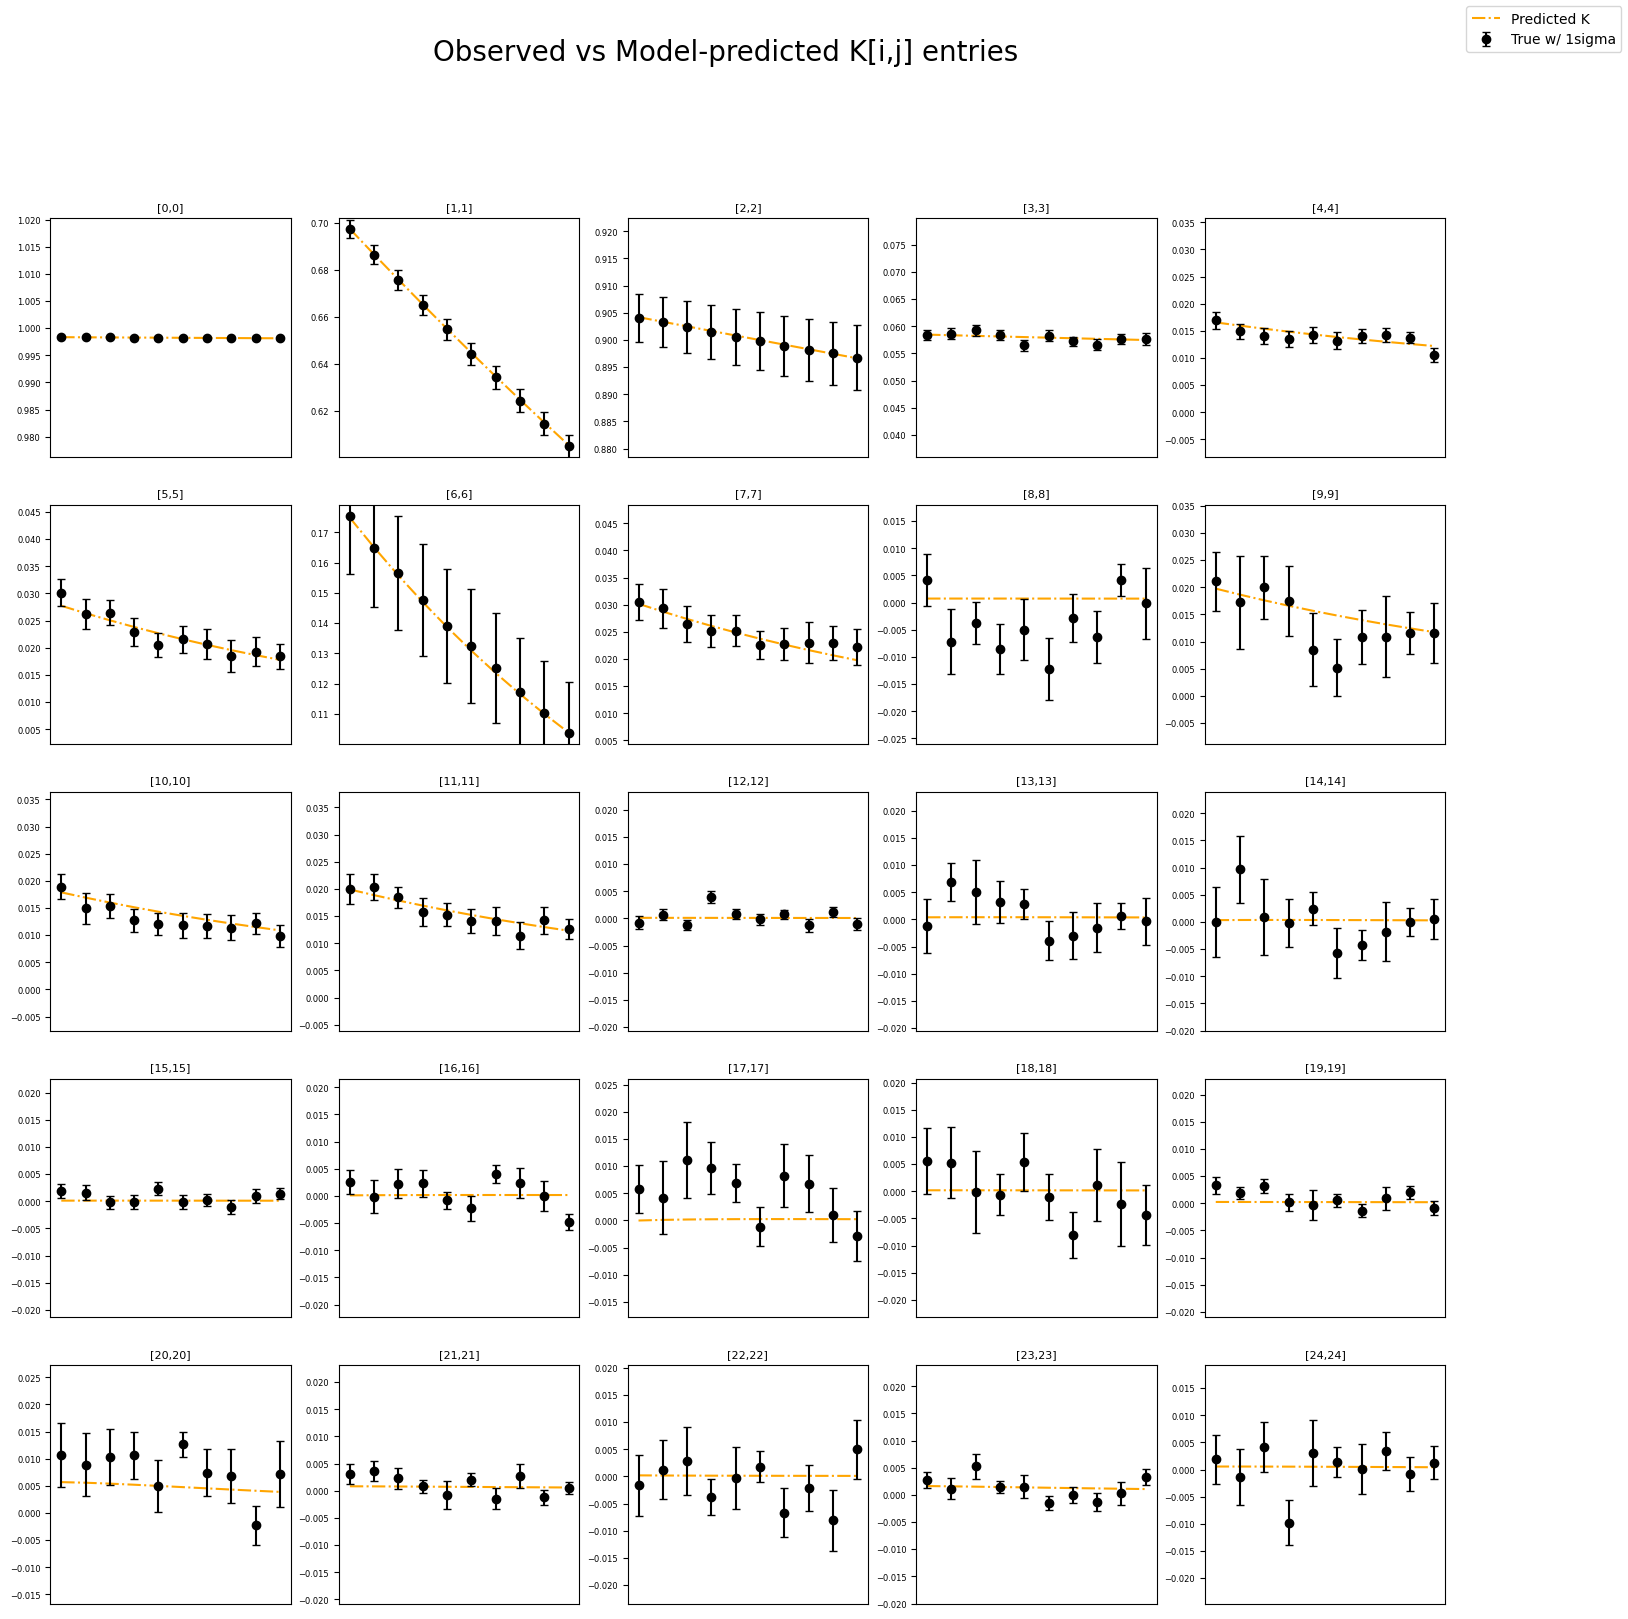

In [27]:
plot_error_bar(Ks_model[en-st:en-st+10], Ks[en:en+10], K_std[en-st:en-st+10], [[i,i] for i in range(25)], y_lim_range = .04)

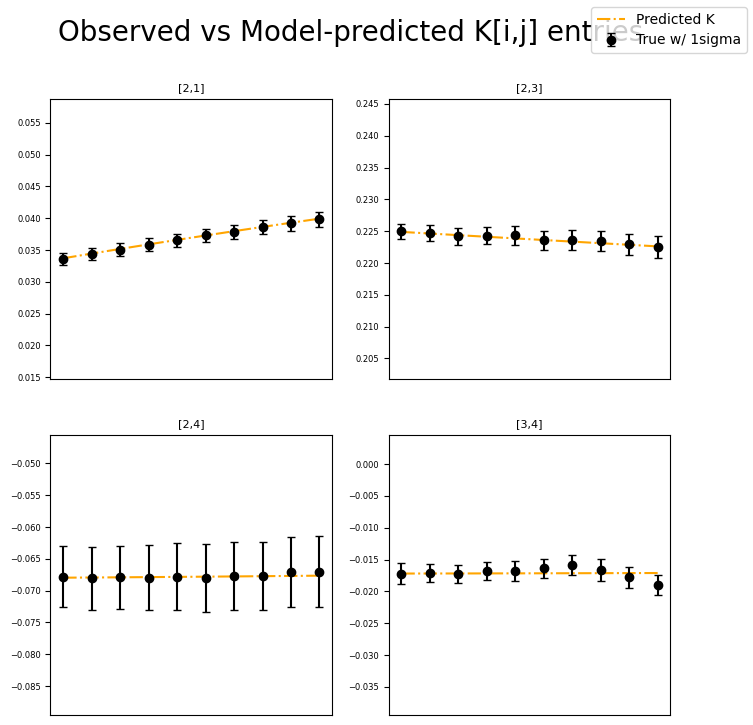

In [29]:
plot_error_bar(Ks_model[en-st:en-st+10], Ks[en:en+10], K_std[en-st:en-st+10], [[2, 1], [2, 3], [2, 4], [3, 4]], y_lim_range = .04, fig_size=(8,8))

In [30]:
Kpred, Ktrue, Kerr = np.asarray(Ks_model[en-st:en-st+10]), np.asarray(Ks[en:en+10]), np.asarray(K_std[en-st:en-st+10])
usage_errorbar = '''
def plot_error_bar(Ks_pred, Ks_true, Ks_err, rc, y_lim_range = .01, fig_size = (18, 18)):
    Ks_pred, Ks_true, Ks_err = np.asarray(Ks_pred), np.asarray(Ks_true), np.asarray(Ks_err)
    t = np.arange(len(Ks_true))
    length = len(rc)
    r, c = [_[0] for _ in rc], [_[1] for _ in rc]
    size = int(np.ceil(np.sqrt(length)))
    fig, axes = plt.subplots(int(np.ceil(length/size)), size, figsize=fig_size, sharex=True)
    fig.suptitle("Observed vs Model-predicted K[i,j] entries", fontsize=20)

    for idx in range(length):
        ax = axes[idx//size, idx%size]
        y_pred = Ks_pred[:, r[idx], c[idx]]
        y_true = Ks_true[:, r[idx], c[idx]]
        y_err = Ks_err[:, r[idx], c[idx]]

        max_true, min_true = np.max(y_true), np.min(y_true)
        if max_true - min_true < y_lim_range:
            mid_true = .5* (max_true + min_true)
            ax.set_ylim([mid_true-y_lim_range*.55, mid_true+y_lim_range*.55])
        else:
            ax.set_ylim([min_true*1.05-max_true*.05, max_true*1.05-min_true*.05])

        ax.plot(t, y_pred, linestyle="dashdot", label='Predicted K', color="orange")
        ax.errorbar(t, y_true, yerr=y_err, fmt='o', capsize=3, color="black", label='True w/ 1sigma')
        ax.set_title(f"[{r[idx]},{c[idx]}]", fontsize=8)
        # Smaller ticks for large grid
        ax.tick_params(axis="both", which="major", labelsize=6)

    # Put legend only once outside the grid
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=10)
    plt.xticks([])
    plt.show()

plot_error_bar(Kpred, Ktrue, Kerr, [[i,i] for i in range(25)], y_lim_range = .04)
'''
np.savez('Panel_1c_BootS.npz', Kpred=Kpred, Ktrue=Ktrue, Kerr=Kerr, usage=usage_errorbar)

In [ ]:
np.load('Panel_1c_BootS.npz')

# tICs and Selections

In [32]:
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

basis_list

[[[-1.43747934, 2], [0.66571087, 2], [-0.14983666, 2], [5.10290513, 2]],
 [[-1.43747934, 2], [0.66571087, 2], [-0.14983666, 2], [5.10290513, 2]]]

Counts per bin: [     1      3     19     67    218    582   1526   3103   6112   9963
  14921  19861  23917  26110  25921  24368  21848  18865  15486  13002
  10633   8874   7609   6402   5420   4699   4124   3356   2945   2634
   2251   2053   1821   1609   1399   1368   1179   1062    990    900
    830    787    737    674    589    567    584    500    520    476
    456    418    406    430    394    409    360    413    385    362
    381    360    366    348    390    426    410    480    527    518
    569    599    717    781    877    979   1126   1369   1538   1775
   2262   2807   3518   4435   5659   7691  10243  14718  21771  33366
  51722  79764 115566 137041 113936  56754  14806   1866    117      4]


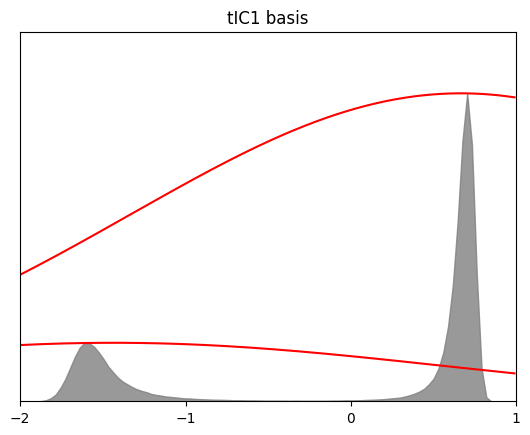

In [43]:
counts, bin_edges = np.histogram(traj_AT[0], bins=100)
print("Counts per bin:", counts)
x_tIC = bin_edges[:-1]+(bin_edges[1]-bin_edges[0])*.5
#plt.plot(x_tIC, counts, color='gray')
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)

x_min, x_max = -2, 1
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[0][0][0], 2, A=26110), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[0][1][0], 2, A=137041), color='r')
#plt.axvline(x=basis_list[0][0][0], color='r', linestyle='--', linewidth=.5)
#plt.axvline(x=basis_list[0][1][0], color='r', linestyle='--', linewidth=.5)
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-2, -1, 0 ,1])
plt.yticks([])
plt.title('tIC1 basis')
plt.show()

In [44]:
usage1 = '''
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = -1.43747934, 0.66571087
x_min, x_max = -2, 1
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=26110), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=137041), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-2, -1, 0 ,1])
plt.yticks([])
plt.title('tIC1 basis')
plt.show()
'''
np.savez('Panel_1b1_tICexpansion.npz', x_tIC=x_tIC, counts=counts, usage=usage1)

Counts per bin: [    3     3    32    73   239   627  1410  2932  5355  8463 12517 18028
 26298 39055 56931 74453 83084 82963 79013 73347 66147 59424 52294 45611
 38481 32131 26456 21182 16767 13111 10065  7405  5390  4001  2868  1860
  1264   837   560   323   213   147    75    55    31    20    16     7
     8     6     4     5     2     3     2     5     7    17    35    46
    71   102   175   188   277   378   510   694   801  1015  1167  1333
  1558  1735  1832  1890  1879  1827  1761  1704  1502  1273  1116   928
   675   584   460   334   223   148    97    65    37    26    17     6
     3     1     0     1]


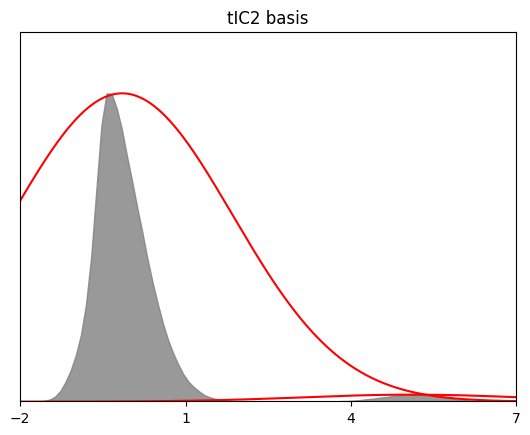

In [51]:
counts, bin_edges = np.histogram(traj_AT[1], bins=100)
print("Counts per bin:", counts)
x_tIC = bin_edges[:-1]+(bin_edges[1]-bin_edges[0])*.5
#plt.plot(x_tIC, counts, color='gray')
plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)

x_min, x_max = -2, 7
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[1][2][0], 2, A=83084), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), basis_list[1][3][0], 2, A=1890), color='r')
#plt.axvline(x=basis_list[0][0][0], color='r', linestyle='--', linewidth=.5)
#plt.axvline(x=basis_list[0][1][0], color='r', linestyle='--', linewidth=.5)
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-2, 1, 4 ,7])
plt.yticks([])
plt.title('tIC2 basis')
plt.show()

In [52]:
usage2 = '''
def gaussian_amp(x, mu, sigma, A=1):
    return A * np.exp(-(x-mu)**2/(2*sigma**2))

plt.fill_between(x_tIC, counts, color='gray', alpha=0.8)
plt.plot(x_tIC, counts, color='gray')
mu1, mu2 = -0.14983666, 5.10290513
x_min, x_max = -2, 7
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu1, 2, A=83084), color='r')
plt.plot(np.arange(x_min, x_max, .01), gaussian_amp(np.arange(x_min, x_max, .01), mu2, 2, A=1890), color='r')
plt.ylim([100, np.max(counts)*1.2])
plt.xlim([x_min, x_max])
plt.xticks([-2, 1, 4 ,7])
plt.yticks([])
plt.title('tIC2 basis')
plt.show()
'''
np.savez('Panel_1b2_tICexpansion.npz', x_tIC=x_tIC, counts=counts, usage=usage2)